In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# Exploratory Data Analysis (EDA)

import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics._regression import mean_absolute_error, mean_squared_error, root_mean_squared_error

## Task info

Your task

Implement a machine learning system that predicts being diagnosed with heart disease

1) Apply EDA to extract useful insights
2) Build your preprocessing pipeline consisting of scaling, label-encoding, one-hot encoding
3) Try the 3 models we covered logistic regression, svm & knn
 
Evaluate your model accuracy, precesion, recall, ......

Kindly deploy on a streamlit app

In [3]:
os.listdir('data/raw/')

['Heart-Disease-Patients-Records.csv']

In [41]:
df = pd.read_csv('data/preprocessed-data/preprocessed-data.csv')

# Data info
- -EDA-1 = 
- A /data/raw/Exam_Score_Prediction.csv 
- B data/feature eng data/feature_eng_data.csv

- -Pre-processed-2
- A data/feature eng data/feature_eng_data.csv
- B data/preprocessed data/pre-processed_data.csv

- -Machine-learning-3 = 
- A /data/preprocessed data/pre-processed_data.csv
- B /artifacts/svm_pipeline.pkl

In [42]:
df.shape

(303, 22)

# Visualation

In [30]:
numerical_columns = df.select_dtypes(exclude=['object']).columns
numerical_columns

Index(['age', 'resisting_blood_pressure', 'cholesterol_level',
       'max_heart_rate_achieved', 'st_depression', 'num_major_vessels'],
      dtype='object')

In [31]:
px.histogram(df, x =numerical_columns, template = 'simple_white', 
             title = 'A quick inspection of Numerical columns distribution',
              marginal = 'box' , barmode='group', nbins=10,)# barmode='group'

# Category Columns

In [32]:
category_columns = df.select_dtypes(include=['O']).columns
category_columns

Index(['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg',
       'exercise_induced_angina', 'st_slope', 'thalassemia', 'diagnosis'],
      dtype='object')

In [33]:
px.histogram( df, x= category_columns, barmode='group', nbins=1 )

# Data visualation
- Distribution & oulieres
## Skewness

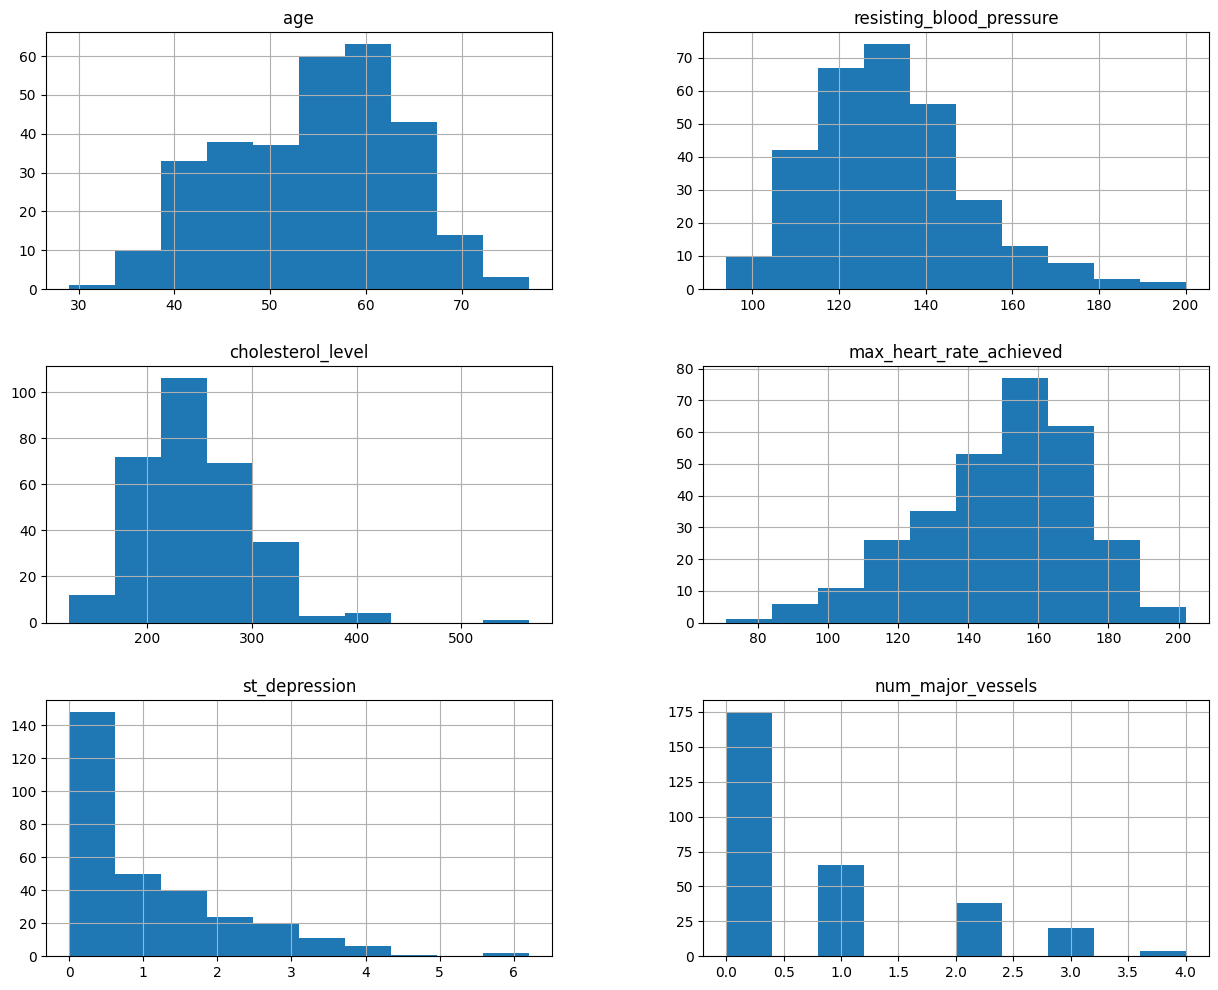

In [34]:
df.hist( figsize= (15, 12));

# SME = Subject Matter Expert

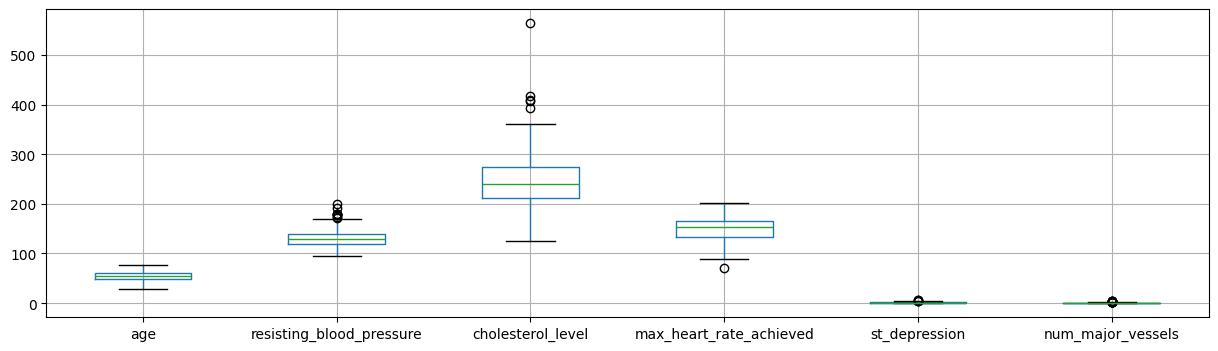

In [35]:
df.boxplot( figsize= ( 15, 4))
plt.xticks( rotation = 0);

In [36]:
df.describe()

,age,resisting_blood_pressure,cholesterol_level,max_heart_rate_achieved,st_depression,num_major_vessels
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,131.602649,246.500000,149.569536,1.043046,0.718543
std,9.04797,17.563394,51.753489,22.903527,1.161452,1.006748
min,29.00000,94.000000,126.000000,71.000000,0.000000,0.000000
25%,48.00000,120.000000,211.000000,133.250000,0.000000,0.000000
50%,55.50000,130.000000,240.500000,152.500000,0.800000,0.000000
75%,61.00000,140.000000,274.750000,166.000000,1.600000,1.000000
max,77.00000,200.000000,564.000000,202.000000,6.200000,4.000000


# Scaling
- log

In [37]:
scaler = StandardScaler()

In [ ]:
# joblib.dump( svm_pipeline,'../artifacts/svm_pipeline.plk' )